<a href="https://colab.research.google.com/github/tettty1981-lang/data-analytics-course/blob/main/HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [6]:
monthly_avg = df.resample('ME')['count'].mean()
monthly_avg.head()

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


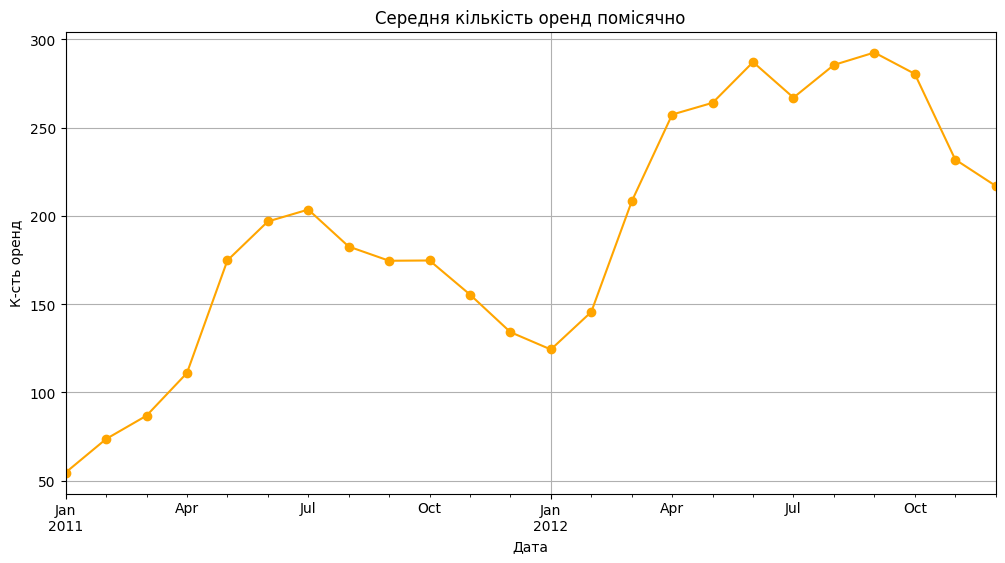

In [20]:
# viz with Pandas
monthly_avg.plot(kind='line',
    figsize=(12, 6),
    marker='o',
    color='orange',
    secondary_y='temp',
    title='Cередня кількість оренд помісячно',
    grid=True
)
plt.xlabel('Дата')
plt.ylabel('К-сть оренд')
plt.show()

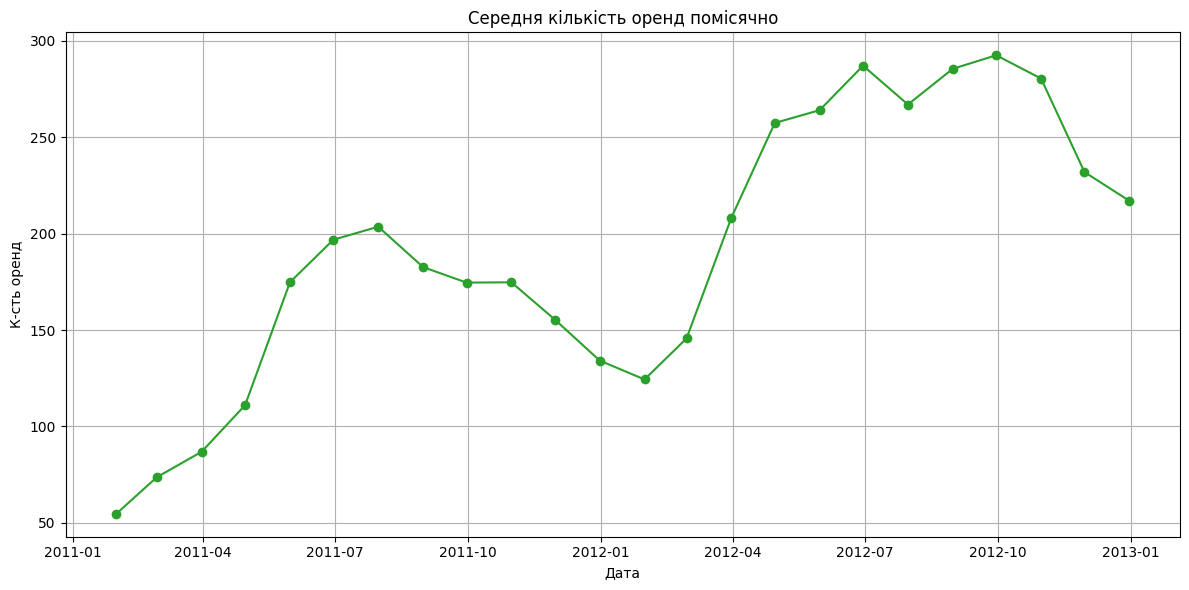

In [21]:
# viz with Matplotlib
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg, 'o-', color= '#2ca02c')
plt.title('Cередня кількість оренд помісячно')
plt.xlabel('Дата')
plt.ylabel('К-сть оренд')
plt.tight_layout()
plt.grid(True)
plt.show()

На цьому етапі деталізації графіка принцип побудови для мене відрізняється не суттєво. Візуалізація теж максимально схожа, за виключенням, що графік починається не від від осі Y у Matplotlib.
Також ми щоразу у Matplotlib пишемо plt. У Pandas не пишемо, але щоб деталізувати графік і щоб він не був базовим, ми теж у Pandas прописуємо/задаємо певні параметри.


## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.



In [22]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

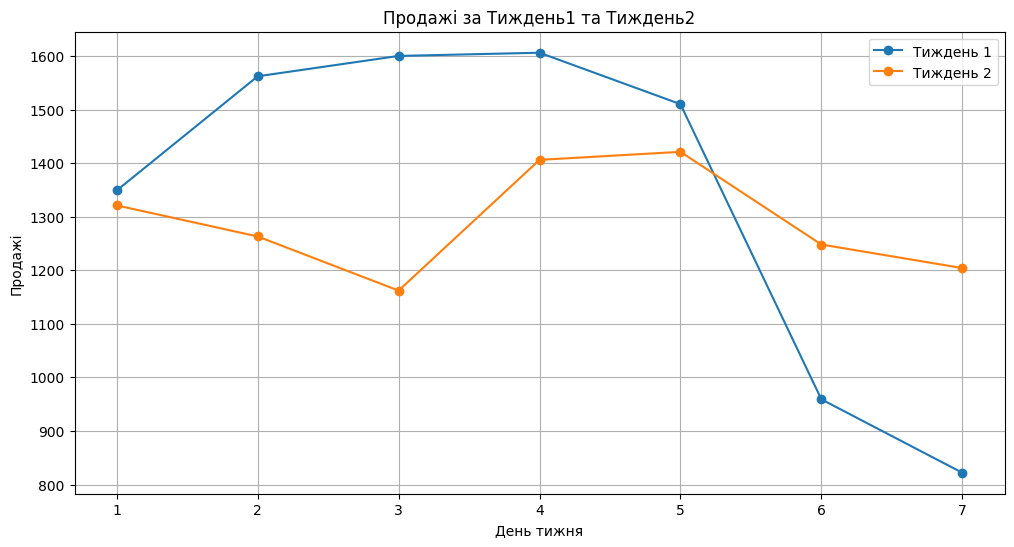

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(days, sales_week1, marker='o', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', label='Тиждень 2')
plt.title('Продажі за Тиждень1 та Тиждень2')
plt.xlabel('День тижня')
plt.ylabel('Продажі')
plt.grid(True)
plt.legend()
plt.show()


**Дайте відповіді на питання:**

**1. Судячи з графіку, в який тиждень проодажі були стабільніше?**

Візуально можемо відповісти, що у другий тиждень.

**2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.**

Можемо порахувати через стандартне відхилення  - np.std()
Нижче розрахунок показує, що std тижня 1 (≈300) більш ніж утричі перевищує std тижня 2 (≈91) — тиждень 2 стабільніший.

In [28]:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

In [29]:
std_week1

np.float64(299.99857142517004)

In [30]:
std_week2

np.float64(90.9060964256355)

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [60]:
temp_avg = df.resample('ME')['temp'].mean()
temp_avg.head()


,temp
datetime,
2011-01-31,8.633782
2011-02-28,11.331076
2011-03-31,14.063184
2011-04-30,17.776879
2011-05-31,21.528596


In [61]:
quarterly_avg = df.resample('QE')['count'].mean()
quarterly_avg.head()

,count
datetime,
2011-03-31,71.905518
2011-06-30,160.940746
2011-09-30,186.994872
2011-12-31,154.787125
2012-03-31,159.476889


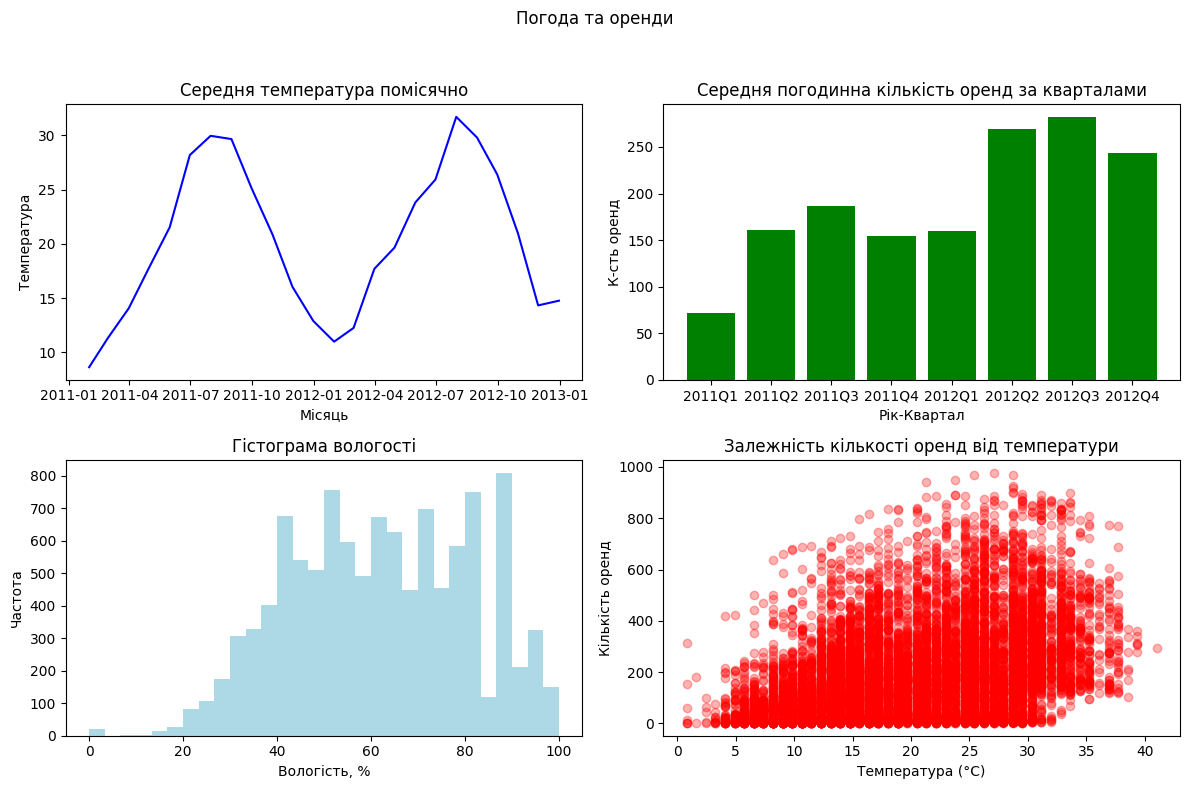

In [62]:
plt.figure(figsize=(12, 8))
# Графік 1
plt.subplot(2, 2, 1)
plt.plot(temp_avg, color='blue')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')

# Графік 2
plt.subplot(2, 2, 2)
plt.bar(quarterly_avg.index.to_period('Q').astype(str), quarterly_avg.values, color='green')
plt.title('Cередня погодинна кількість оренд за кварталами')
plt.xlabel('Рік-Квартал')
plt.ylabel('К-сть оренд')

# Графік 3
plt.subplot(2, 2, 3)
plt.hist(df['humidity'],bins=30, color='lightblue')
plt.title('Гістограма вологості')
plt.xlabel('Вологість, %')
plt.ylabel('Частота')

# Графік 4
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], color='red', alpha=0.3)
plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.suptitle('Погода та оренди')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

plt.subplot() — якщо захочеш повернутись і щось додати до графіка 1 пізніше — треба знову викликати plt.subplot(2,2,1), щоб його "активувати".

plt.subplots() — ми одразу отримуємо ax — масив з посиланнями на всі підграфіки одночасно, і звертаєшся до потрібного напряму за індексом (ax[0,0], ax[1,1]), незалежно від порядку і без "активації". Кожен підграфік — окремий об'єкт, з яким можна працювати в будь-який момент.

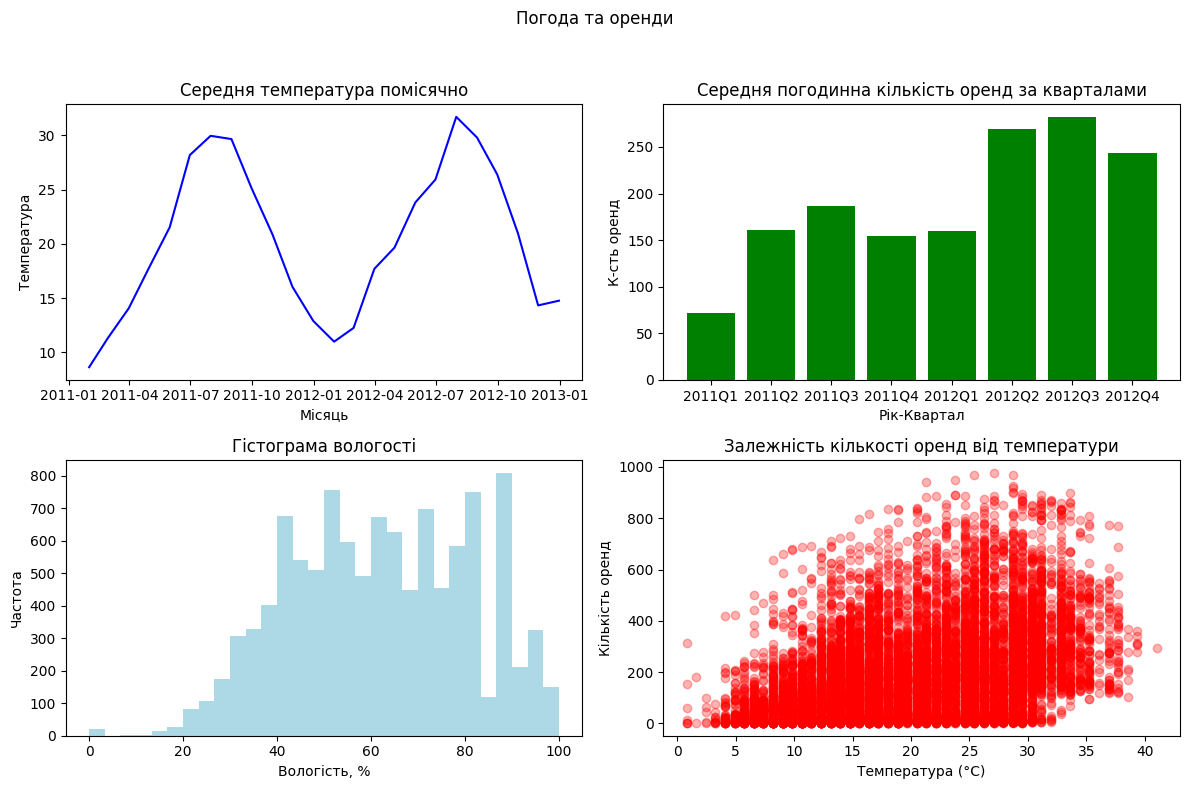

In [70]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Графік 1
ax[0, 0].plot(temp_avg, color='blue')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')

# Графік 2
ax[0, 1].bar(quarterly_avg.index.to_period('Q').astype(str), quarterly_avg.values, color='green')
ax[0, 1].set_title('Cередня погодинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Рік-Квартал')
ax[0, 1].set_ylabel('К-сть оренд')

# Графік 3
ax[1, 0].hist(df['humidity'],bins=30, color='lightblue')
ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість, %')
ax[1, 0].set_ylabel('Частота')


# Графік 4
ax[1, 1].scatter(df['temp'], df['count'], color='red', alpha=0.3)
ax[1, 1].set_title('Залежність кількості оренд від температури')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')

plt.suptitle('Погода та оренди')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [71]:
import matplotlib.dates as mdates

In [74]:
monthly_stats = df.resample('ME')['count'].agg(['mean', 'max', 'min'])
monthly_stats.head()

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1


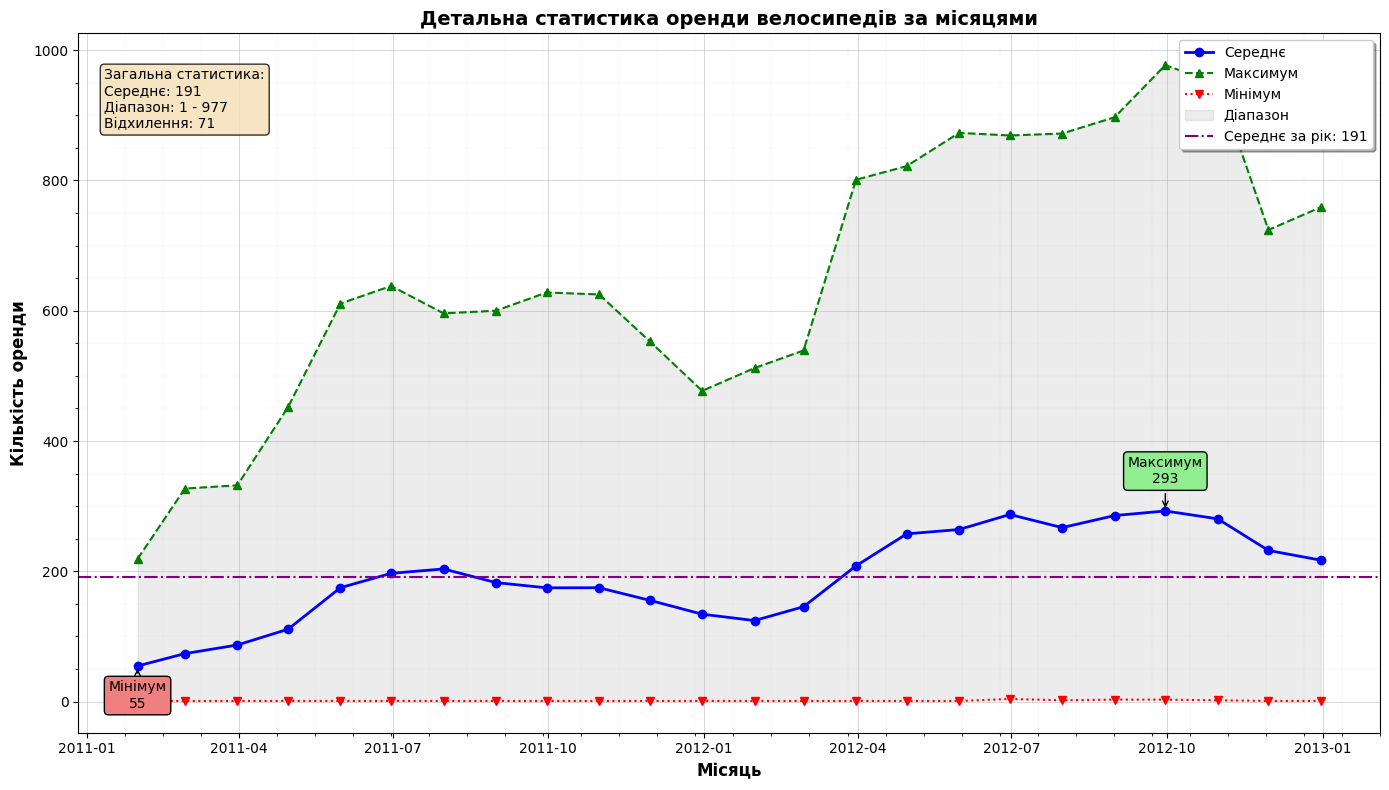

In [82]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(monthly_stats.index, monthly_stats['mean'], color='blue', linestyle='-', marker='o', linewidth=2, label='Середнє')
ax.plot(monthly_stats.index, monthly_stats['max'], color='green', linestyle='--', marker='^', linewidth=1.5, label='Максимум')
ax.plot(monthly_stats.index, monthly_stats['min'], color='red', linestyle=':', marker='v', linewidth=1.5, label='Мінімум')

ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'], alpha=0.15, color='gray', label='Діапазон')

yearly_mean = monthly_stats['mean'].mean()
ax.axhline(yearly_mean, color='purple', linestyle='-.', linewidth=1.5, label=f'Середнє за рік: {yearly_mean:.0f}')

max_month = monthly_stats['mean'].idxmax()
max_value = monthly_stats['mean'].max()
min_month = monthly_stats['mean'].idxmin()
min_value = monthly_stats['mean'].min()

ax.annotate(f'Максимум\n{max_value:.0f}', xy=(max_month, max_value), xytext=(0, 20), textcoords='offset points',
            ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen'), arrowprops=dict(arrowstyle='->'))
ax.annotate(f'Мінімум\n{min_value:.0f}', xy=(min_month, min_value), xytext=(0, -30), textcoords='offset points',
            ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral'), arrowprops=dict(arrowstyle='->'))

ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.4)

ax.legend(loc='upper right', shadow=True, fancybox=True, fontsize=10)

stats_text = (f"Загальна статистика:\n"
              f"Середнє: {monthly_stats['mean'].mean():.0f}\n"
              f"Діапазон: {monthly_stats['min'].min():.0f} - {monthly_stats['max'].max():.0f}\n"
              f"Відхилення: {monthly_stats['mean'].std():.0f}")
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Детальна статистика оренди велосипедів за місяцями', fontsize=14, fontweight='bold')
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()




**1. Перевага анотацій**

Не треба оцінювати значення "на око" по осі — точне число і сама точка вже підписані просто на графіку. Швидше й точніше, особливо коли графік показуєш комусь іншому (звіт, презентація) — людині не треба вглядатися в шкалу.

**2. Для чого fill_between()**

Перетворює дві окремі лінії (мін і макс) на візуальний "коридор" — суцільну зафарбовану область. Це дає миттєве відчуття ширини розкиду значень у кожному місяці, а не просто дві лінії, які треба подумки "з'єднувати" очима.

**3. Як текстовий блок допомагає**

Лінії графіка показують динаміку (як змінюється показник у часі), а текстовий блок дає загальні підсумкові цифри одним поглядом — без потреби рахувати самому чи виводити окремо в коді. Це зведення "по всьому періоду", а не по конкретній точці.